In [17]:
import torch
import matplotlib.pyplot as plt
torch.manual_seed(0)

In [18]:
X = torch.tensor([[0.,0.],[0.,1.],[1.,0.],[1.,1.]])
y_and = torch.tensor([[0.],[0.],[0.],[1.]])
y_or  = torch.tensor([[0.],[1.],[1.],[1.]])
y_xor = torch.tensor([[0.],[1.],[1.],[0.]])

In [19]:
eps = 1e-7
def bce_loss(p, y):
    return - (y * torch.log(p + eps) + (1 - y) * torch.log(1 - p + eps)).mean()

In [20]:
w_and = torch.randn(2, 1, requires_grad=True)
b_and = torch.zeros(1, requires_grad=True)
loss_and = []

with torch.no_grad():
    w_and *= 0.1

lr = 0.1
for _ in range(1000):
    logits = X @ w_and + b_and
    p = torch.sigmoid(logits)
    loss = bce_loss(p, y_and)
    loss.backward()

    with torch.no_grad():
        w_and -= lr * w_and.grad
        b_and -= lr * b_and.grad

    w_and.grad.zero_()
    b_and.grad.zero_()
    loss_and.append(loss)

print("AND probs:", torch.sigmoid(X.mm(w_and) + b_and).detach().squeeze().tolist())
print("AND preds:", (torch.sigmoid(X.mm(w_and) + b_and) > 0.5).int().view(-1).tolist())

AND probs: [0.008296731859445572, 0.14926327764987946, 0.14956286549568176, 0.7866982817649841]
AND preds: [0, 0, 0, 1]


In [21]:
w_or = torch.randn(2, 1, requires_grad=True)
b_or = torch.zeros(1, requires_grad=True)
loss_or = []

with torch.no_grad():
    w_or *= 0.1

lr = 0.1
for _ in range(1000):
    logits = X @ w_or + b_or
    p = torch.sigmoid(logits)
    loss = bce_loss(p, y_or)
    loss.backward()

    with torch.no_grad():
        w_or -= lr * w_or.grad
        b_or -= lr * b_or.grad

    w_or.grad.zero_()
    b_or.grad.zero_()
    loss_or.append(loss)

print("OR probs :", torch.sigmoid(X @ w_or + b_or).detach().squeeze().tolist())
print("OR preds :", (torch.sigmoid(X @ w_or + b_or) > 0.5).int().view(-1).tolist())

OR probs : [0.18853215873241425, 0.9274477362632751, 0.9262844324111938, 0.9985557198524475]
OR preds : [0, 1, 1, 1]


In [22]:
W1 = torch.randn(2, 4, requires_grad=True)
b1 = torch.zeros(4, requires_grad=True)
W2 = torch.randn(4, 1, requires_grad=True)
b2 = torch.zeros(1, requires_grad=True)
loss_xor = []

with torch.no_grad():
    W1 *= 0.5
    W2 *= 0.5

lr = 0.1
for _ in range(5000):
    h = torch.tanh(X @ W1 + b1)
    logits = h @ W2 + b2
    p = torch.sigmoid(logits)
    loss = bce_loss(p, y_xor)
    loss.backward()

    with torch.no_grad():
        for param in (W1, b1, W2, b2):
            param -= lr * param.grad
            param.grad.zero_()
    
    loss_xor.append(loss)

out = torch.sigmoid(torch.tanh(X @ W1 + b1) @ W2 + b2)
print("XOR probs:", out.detach().squeeze().tolist())
print("XOR preds:", (out > 0.5).int().view(-1).tolist())

XOR probs: [0.0022503361105918884, 0.9970122575759888, 0.9949977397918701, 0.005370234604924917]
XOR preds: [0, 1, 1, 0]


In [ ]:
loss_and = [l.detach().item() for l in loss_and]
loss_or  = [l.detach().item() for l in loss_or]
loss_xor = [l.detach().item() for l in loss_xor]

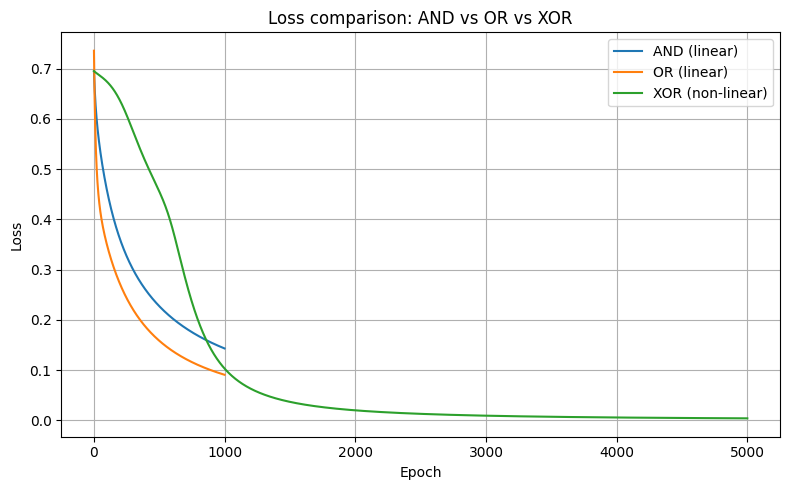

In [25]:
plt.figure(figsize=(8,5))
plt.plot(loss_and, label="AND (linear)")
plt.plot(loss_or,  label="OR (linear)")
plt.plot(loss_xor, label="XOR (non-linear)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss comparison: AND vs OR vs XOR")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
